Given that SVM is known to be very good at binary classification and that our predictions got better as we removed collinear features, I want to combine the best of both worlds and do an SVM on a principle-component reduced dataset so all our features are non-collinear. I also want to run the PCA-pruned lower dimension model on logistic regression again.

First, let's do SVM on the unchanged dataset

In [8]:
import pandas as pd
df = pd.read_csv("../../data/aggregated_rolling_features.csv")
df.shape

(5539, 97)

Drop arbitrary features

In [9]:
to_drop = []
to_drop.extend([f"team{i}_player{k}_id" for i in range(1,3) for k in range(1,6)])
to_drop.extend([f"team{i}_id" for i in range(1,3)])
to_drop.extend([f"team{i}" for i in range(1,3)])
to_drop.extend(["tournament", "match_id", "game_id", "map_id", "map_name", "datetime", "Unnamed: 0"])
df_dropped = df.drop(to_drop, axis=1).copy()
df_dropped

,team1_win,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score,previous_10_games_team1_average_kills,previous_10_games_team1_std_kills,previous_10_games_team1_range_kills,previous_10_games_team1_max_kills,previous_10_games_team1_min_kills,previous_10_games_team1_median_kills,...,previous_10_games_team2_range_kast,previous_10_games_team2_max_kast,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff
0,0,3.0,13.000000,13.000000,16.000000,0.000000e+00,0.0,16.000000,16.000000,16.000000,...,0.00,70.000000,70.000000,70.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000
1,1,3.0,12.333333,12.333333,15.600000,4.127953e+00,10.0,22.000000,12.000000,13.000000,...,25.00,83.300000,58.300000,58.300000,-0.600000,3.136877,9.0,4.000000,-5.000000,0.000000
2,1,3.0,11.600000,11.600000,15.100000,2.083267e+00,5.5,18.500000,13.000000,14.000000,...,17.30,75.000000,57.700000,60.100000,-1.600000,5.885576,17.5,8.500000,-9.000000,-1.500000
3,1,3.0,11.571429,11.571429,14.612903,1.776357e-15,0.0,14.612903,14.612903,14.612903,...,0.00,71.535484,71.535484,71.535484,-0.032258,0.000000,0.0,-0.032258,-0.032258,-0.032258
4,1,3.0,10.666667,10.666667,13.600000,4.363485e+00,13.0,21.000000,8.000000,13.000000,...,33.30,60.000000,26.700000,33.300000,-9.000000,2.280351,6.0,-6.000000,-12.000000,-9.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,0,3.0,13.400000,9.500000,14.140000,9.200000e-01,2.6,15.400000,12.800000,14.200000,...,6.89,77.400000,70.510000,76.760000,0.780000,2.465279,6.4,3.500000,-2.900000,1.800000
5535,0,3.0,9.700000,11.100000,14.680000,1.175415e+00,3.3,16.600000,13.300000,14.900000,...,6.96,78.300000,71.340000,76.820000,0.920000,2.741095,7.0,3.700000,-3.300000,2.300000
5536,1,3.0,11.000000,10.700000,14.440000,6.590903e-01,1.7,15.400000,13.700000,14.600000,...,6.96,79.800000,72.840000,75.820000,1.140000,2.793278,7.1,3.900000,-3.200000,2.700000
5537,0,5.0,11.400000,12.700000,14.780000,2.594147e+00,6.8,17.500000,10.700000,14.900000,...,5.71,83.730000,78.020000,82.000000,4.280000,3.398470,8.7,7.800000,-0.900000,5.200000


In [10]:
X = df_dropped.drop("team1_win", axis=1)
y = df_dropped.team1_win

In [11]:
X_numerical = X.drop("bestOf", axis=1)
X_categorical = X.bestOf

Standardize and one-hot encode

In [12]:
from sklearn.preprocessing import StandardScaler
from math import ceil
stnd = StandardScaler().set_output(transform="pandas")
split_point = ceil(len(df_dropped) * 0.8)
train_numerical = X_numerical.iloc[:split_point] # 0 to split_point - 1
test_numerical = X_numerical.iloc[split_point:] # split_point to len(df)
train_cat = X_categorical.iloc[:split_point]
test_cat = X_categorical.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]
train_numerical = stnd.fit_transform(train_numerical)
test_numerical = stnd.transform(test_numerical)
train_cat = pd.get_dummies(train_cat, prefix="bestOf", drop_first=True, dtype=int)
test_cat = pd.get_dummies(test_cat, prefix="bestOf", drop_first=True, dtype=int)
X_train = pd.concat([train_numerical, train_cat], axis=1)
X_test = pd.concat([test_numerical, test_cat], axis=1)
display(X_train)
display(X_test)

,team1_previous_10_average_map_score,team2_previous_10_average_map_score,previous_10_games_team1_average_kills,previous_10_games_team1_std_kills,previous_10_games_team1_range_kills,previous_10_games_team1_max_kills,previous_10_games_team1_min_kills,previous_10_games_team1_median_kills,previous_10_games_team1_average_deaths,previous_10_games_team1_std_deaths,...,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff,bestOf_3.0,bestOf_5.0
0,1.067406,1.103525,1.191579,-2.267983,-2.232999,-0.412393,2.477353,1.117133,0.481263,-2.420802,...,0.563877,-0.400940,0.744679,-2.358334,-2.318953,-0.792708,2.108424,0.709155,1,0
1,0.694554,0.753637,0.887984,3.156345,2.427842,2.609393,-0.017376,-1.000761,0.481263,4.429077,...,-1.840127,-3.414365,-0.299688,1.205328,1.300430,0.550491,-1.057503,0.108085,1,0
2,0.284417,0.368761,0.508491,0.469529,0.330464,0.846685,0.606306,-0.294796,-0.534503,3.051541,...,-1.963409,-2.950761,-0.952418,4.327997,4.718737,2.565289,-3.168122,-0.793522,1,0
3,0.268438,0.353766,0.138792,-2.267983,-2.232999,-1.110977,1.612245,0.137892,0.223811,-2.420802,...,0.879373,-0.005464,0.070893,-2.358334,-2.318953,-1.254884,1.563748,0.088695,1,0
4,-0.237576,-0.121081,-0.629988,3.465844,3.826094,2.105762,-2.512105,-1.000761,-7.064424,1.510645,...,-8.332992,-9.853307,-5.782617,0.232268,0.093969,-3.926839,-4.751085,-5.301553,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4427,1.067406,-0.051104,0.204897,1.381192,1.449065,0.846685,-0.890531,0.411169,-0.621568,0.051191,...,1.854231,2.058736,1.867374,-1.409474,-1.313569,0.640037,2.477782,1.610762,1,0
4428,0.955551,1.313457,0.144178,-0.666354,-0.555096,-0.362030,0.294465,0.481765,-0.708634,0.535262,...,0.818660,1.438022,1.671555,-0.043013,-0.469046,1.042997,1.844597,0.769263,1,0
4429,0.060706,0.526211,-0.022799,-0.468170,-0.368663,-0.412393,-0.017376,0.199379,-0.636079,0.645259,...,0.880301,1.237127,1.632391,-0.470159,-0.629907,0.998224,2.002893,1.009691,1,0
4430,-0.218933,0.368761,-0.402292,-0.591349,-0.601705,-0.865660,-0.266849,-0.012410,-1.216517,0.286723,...,0.775511,0.485059,1.332135,-0.211222,-0.026677,0.998224,1.211411,0.889477,1,0


,team1_previous_10_average_map_score,team2_previous_10_average_map_score,previous_10_games_team1_average_kills,previous_10_games_team1_std_kills,previous_10_games_team1_range_kills,previous_10_games_team1_max_kills,previous_10_games_team1_min_kills,previous_10_games_team1_median_kills,previous_10_games_team1_average_deaths,previous_10_games_team1_std_deaths,...,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff,bestOf_3.0,bestOf_5.0
4432,0.578038,-0.018424,0.538851,0.558411,0.423680,0.040875,-0.516322,1.328923,-0.171729,0.195478,...,-0.272388,-1.098921,-0.599944,-1.609572,-1.554861,-1.240441,0.578226,-0.432879,1,0
4433,0.060706,0.158829,-0.538910,-0.096979,-0.089012,-0.311666,-0.266849,-0.153603,-2.000107,-0.582787,...,0.093350,0.276437,0.313877,1.137022,1.018923,0.550491,-0.688145,-0.252558,1,0
4434,0.396273,-0.785868,-0.569269,-0.423817,-0.508488,-0.613845,-0.079744,-0.365393,-2.217771,-0.667321,...,-0.292935,-0.207771,-0.234416,0.528227,0.415692,-0.255429,-0.846441,-0.492986,1,0
4435,-0.330789,0.368761,-0.736246,-0.846380,-0.788138,-0.815297,0.044992,-0.930165,-2.116195,-0.356458,...,-0.011440,-0.207771,0.000567,0.699825,0.697200,0.057984,-0.846441,-0.252558,1,0
4436,0.508128,-0.995800,-0.174596,-0.697710,-0.508488,-0.362030,0.232097,-0.294796,0.495774,-1.377989,...,-0.995644,-0.524567,-0.730490,-0.160605,0.013539,-0.524068,-0.635380,-0.492986,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,1.291117,-0.733384,-0.220136,-1.059059,-1.021180,-0.714571,0.481570,-0.153603,0.147511,0.118386,...,0.668667,1.340150,0.601078,0.442356,0.254831,0.326624,0.050571,1.190012,1,0
5535,-0.778211,0.106346,0.189717,-0.723432,-0.694921,-0.110214,0.793411,0.340572,0.568328,0.356171,...,0.839207,1.355604,0.692460,0.755697,0.496123,0.416171,-0.160491,1.490548,1,0
5536,-0.051150,-0.103587,0.007560,-1.401907,-1.440656,-0.714571,1.042884,0.128783,0.611861,0.062331,...,1.147413,1.098046,0.836061,0.814980,0.536338,0.505717,-0.107725,1.730976,1,0
5537,0.172561,0.946076,0.265616,1.140850,0.936373,0.343054,-0.828163,0.340572,-0.505481,-0.375262,...,2.211750,2.689753,2.885632,1.502511,1.179784,2.251876,1.105880,3.233653,0,1


# First, we will train an SVM on the original feature space with tuned hyperparameters of gamma and the box parameter

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np
grid = {"C": np.logspace(-5, 5, 11), "gamma": np.logspace(-5, 5, 11)}
svc = SVC()
cv = GridSearchCV(svc, param_grid=grid, n_jobs=-1, cv=TimeSeriesSplit(), verbose=2)
cv.fit(X_train, y_train)

Fitting 5 folds for each of 121 candidates, totalling 605 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.e-05...e+04, 1.e+05]), 'gamma': array([1.e-05...e+04, 1.e+05])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

Let's examine what the ideal parameter is

In [15]:
cv.best_params_

{'C': np.float64(100.0), 'gamma': np.float64(0.0001)}

It opted for a very small alpha and larger slack. The small alpha indicates larger islands of influence around each point, leading to a smoother boundary. A lot of variation in the train set apparently does not generalize well.

In [16]:
cv.best_score_

np.float64(0.5712737127371275)

The best score it got on validation was 0.571.

In [17]:
cv.best_estimator_.score(X_test, y_test)

0.5645889792231256

It got a 0.5645 on the test set which is almost 1% better than baseline.

# Now let's redo it with PCA

In [18]:
from sklearn.decomposition import PCA
pca = PCA()
X_train_transormed = pca.fit_transform(X_train)
X_test_transformed = pca.transform(X_test)

I had ChatGPT generate the graph of explained variance ratios

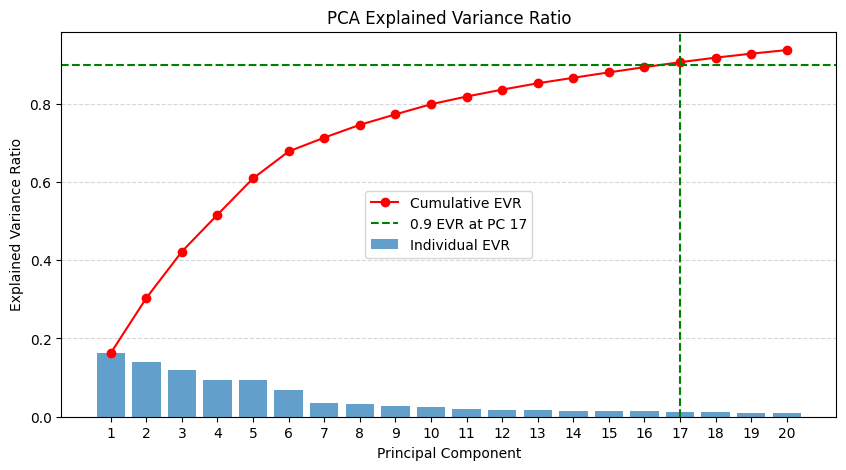

In [22]:
import matplotlib.pyplot as plt

evr = pca.explained_variance_ratio_
cumulative_evr = evr.cumsum()
threshold_pc = np.argmax(cumulative_evr >= 0.9) + 1
plot_limit = min(20, len(evr))
x = np.arange(1, plot_limit + 1)

plt.figure(figsize=(10, 5))
plt.bar(x, evr[:plot_limit], alpha=0.7, label='Individual EVR')
plt.plot(x, cumulative_evr[:plot_limit], color='red', marker='o', label='Cumulative EVR')
if threshold_pc <= plot_limit:
    plt.axvline(threshold_pc, color='green', linestyle='--', label=f'0.9 EVR at PC {threshold_pc}')
    plt.axhline(0.9, color='green', linestyle='--')
plt.xticks(x)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

At PC-17 we hit 0.9 total explained variance, so we keep 1-17

In [23]:
X_train_transformed_slice = X_train_transormed[:, :17]
X_test_transformed_slice = X_test_transformed[:, :17]

Do a new grid search

In [24]:
grid = {"C": np.logspace(-5, 5, 11), "gamma": np.logspace(-5, 5, 11)}
svc = SVC()
cv = GridSearchCV(svc, param_grid=grid, n_jobs=-1, cv=TimeSeriesSplit(), verbose=2)
cv.fit(X_train_transformed_slice, y_train)

Fitting 5 folds for each of 121 candidates, totalling 605 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.e-05...e+04, 1.e+05]), 'gamma': array([1.e-05...e+04, 1.e+05])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [25]:
cv.best_params_

{'C': np.float64(1000.0), 'gamma': np.float64(1e-05)}

Even smaller gamma this time with slightly more slack this time, meaning even more predictless noise in the variation of the training data

In [26]:
cv.best_score_

np.float64(0.5636856368563686)

This one did worse on validation

In [27]:
cv.best_estimator_.score(X_test_transformed_slice, y_test)

0.5682023486901535

It does however do better on the test set which was unexpected. Slightly over 1% more accurate than the baseline.

# As a final test, I noticed that one of our best models was logistic regression with collinear features removed, and PCA removes collinearity more cleanly, so lets give that logistic regressor a shot as well with this new PCA dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=10**12) # no regularization
lr.fit(X_train_transformed_slice, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000000000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For 

In [30]:
weights = pd.DataFrame()
weights["Feature"] = [f"PC{k}" for k in range(1, 18)]
weights["Weight"] = lr.coef_[0]
weights = weights.sort_values(by="Weight", ascending = False)
display(weights.head(10))
display(weights.tail(10))

,Feature,Weight
13,PC14,0.124645
1,PC2,0.096526
16,PC17,0.094789
11,PC12,0.034556
7,PC8,0.027225
4,PC5,0.020795
5,PC6,0.018110
2,PC3,0.015258
12,PC13,0.008141
8,PC9,0.006501


,Feature,Weight
2,PC3,0.015258
12,PC13,0.008141
8,PC9,0.006501
6,PC7,0.002458
10,PC11,-0.004345
0,PC1,-0.006180
14,PC15,-0.006191
3,PC4,-0.014354
15,PC16,-0.048504
9,PC10,-0.072736


What exactly this model is valuing is hard to interpret since PCs don't cleanly correspond to much. PC14 leads by a large margin.

In [31]:
lr.score(X_test_transformed_slice, y_test)

0.5582655826558266

It does pretty much the same as the baseline.